# Notebook 08 — Multi-SOC Mechanism Fingerprint Scan

## Goal

This notebook extends the SOC = 50% mechanism-to-observable fingerprint scan to multiple SOC points.

The goal is to test whether the mechanism-specific observable fingerprints identified at SOC = 50% remain stable across the battery state trajectory, or whether they become SOC-dependent.

## Scientific context

Previous notebooks established:

- `Ds_p` reduction mainly affects relaxation / tau2 descriptors.
- `j0_n` reduction mainly increases short-window Ri.
- `j0_p` reduction produces a weaker Ri-sensitive response.
- `contact_R` produces a pure ohmic/contact fingerprint when `"contact resistance": "true"` is enabled.
- Temperature is active mainly through Ri-sensitive pathways under the current Chen2020 isothermal configuration.

The next methodological question is:

Do these fingerprints remain valid across SOC?

Core mapping:

DFN-level perturbation  
→ HPPC response at each SOC  
→ CDEFG / Ri / tau extraction  
→ SOC-resolved mechanism fingerprint

## SOC points

This notebook evaluates:

- SOC = 10%
- SOC = 30%
- SOC = 50%
- SOC = 70%
- SOC = 90%

## Perturbation cases

Representative perturbations are selected from the corrected Tier-0 scan:

1. `baseline`
2. `Ds_p_x0p5`
3. `j0_n_x0p5`
4. `j0_p_x0p5`
5. `contact_R_5mOhm`

This gives 25 HPPC simulations in total.

## Workflow

1. Import packages and audit version/path.
2. Define shared HPPC protocol.
3. Define reusable runner and observable extraction functions.
4. Build multi-SOC case table.
5. Run all SOC × perturbation cases.
6. Extract:
   - CDEFG points
   - Ri_CD / Ri_EF
   - tau1/tau2 descriptors from 60 s and 300 s windows
   - contact overpotential
7. Build SOC-resolved fingerprint tables.
8. Plot mechanism-specific observable maps across SOC.
9. Identify whether fingerprints are SOC-stable or SOC-dependent.

## Expected outputs

- `data/multi_soc_fingerprint_scan_results.csv`
- `data/multi_soc_fingerprint_drift_table.csv`
- SOC-resolved Ri and tau2 maps
- mechanism-specific fingerprint plots

## Interpretation boundary

This notebook does not model cycle aging or SOH evolution.

It evaluates state dependence of selected mechanism-to-observable fingerprints under:

- Chen2020 DFN
- isothermal default 25 °C condition
- 1C 10 s discharge pulse
- 600 s relaxation
- selected representative perturbations

The correct conclusion format is:

“Under the present HPPC protocol, the observable fingerprint of mechanism X is stable or state-dependent across the tested SOC range.”

This notebook must not claim general aging behavior across all temperatures, chemistries, or cycling histories.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — Shared HPPC configuration（统一 HPPC 协议配置）

SOC_POINTS = [0.10, 0.30, 0.50, 0.70, 0.90]

PULSE_C_RATE = "1C"
PULSE_DURATION_S = 10
REST_BEFORE_S = 60
RELAXATION_S = 600
OUTPUT_PERIOD = "0.1 seconds"

COMMON_MODEL_OPTIONS = {
    "contact resistance": "true",
}

print("SOC points:", SOC_POINTS)
print("Pulse:", PULSE_C_RATE, "for", PULSE_DURATION_S, "s")
print("Rest before pulse:", REST_BEFORE_S, "s")
print("Relaxation:", RELAXATION_S, "s")
print("Output period:", OUTPUT_PERIOD)
print("Common model options:", COMMON_MODEL_OPTIONS)

SOC points: [0.1, 0.3, 0.5, 0.7, 0.9]
Pulse: 1C for 10 s
Rest before pulse: 60 s
Relaxation: 600 s
Output period: 0.1 seconds
Common model options: {'contact resistance': 'true'}


In [3]:
# Cell 3 — HPPC runner function（多 SOC HPPC 仿真运行函数）

def run_hppc_case(case_name, parameter_values, soc_init, model_options=None):
    """
    Run one HPPC-style pulse at a given initial SOC:
    rest -> 1C discharge pulse -> relaxation.

    PyBaMM convention:
    +I = discharge
    -I = charge
    """
    if model_options is None:
        model_options = COMMON_MODEL_OPTIONS.copy()

    model = pybamm.lithium_ion.DFN(model_options)

    experiment = pybamm.Experiment(
        [
            f"Rest for {REST_BEFORE_S} seconds",
            f"Discharge at {PULSE_C_RATE} for {PULSE_DURATION_S} seconds",
            f"Rest for {RELAXATION_S} seconds",
        ],
        period=OUTPUT_PERIOD,
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=parameter_values,
        experiment=experiment,
    )

    sim.set_initial_soc(soc_init, direction="discharge")
    solution = sim.solve()

    df = pd.DataFrame(
        {
            "case": case_name,
            "soc_init": soc_init,
            "time_s": solution["Time [s]"].entries,
            "voltage_V": solution["Terminal voltage [V]"].entries,
            "current_A_pybamm": solution["Current [A]"].entries,
        }
    )

    df["time_rel_s"] = df["time_s"] - df["time_s"].iloc[0]
    df["current_A_exp"] = -df["current_A_pybamm"]

    try:
        df["contact_overpotential_V"] = solution["Contact overpotential [V]"].entries
    except KeyError:
        df["contact_overpotential_V"] = np.nan

    return df, solution


print("[OK] run_hppc_case() defined")

[OK] run_hppc_case() defined


In [4]:
# Cell 4 — CDEFG and Ri extraction（CDEFG 点位与 Ri 提取）

def extract_cdefg_and_ri(df, current_threshold_A=0.1):
    """
    Extract CDEFG-style HPPC points and fixed-window Ri values.
    """
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    pulse_mask = np.abs(i) > current_threshold_A
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(t[pulse_start_idx])
    t_end = float(t[pulse_end_idx])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + RELAXATION_S - 10) & (t <= t_end + RELAXATION_S)

    windows = {
        "C": C_window,
        "D": D_window,
        "E": E_window,
        "F": F_window,
        "G": G_window,
    }

    points = {}
    for label, mask in windows.items():
        if mask.sum() == 0:
            raise ValueError(f"{label} window has no data points.")
        points[label] = {
            "t_s": float(np.median(t[mask])),
            "U_V": float(np.median(u[mask])),
            "n_points": int(mask.sum()),
        }

    I_C = float(np.median(i[C_window]))
    I_D = float(np.median(i[D_window]))
    I_E = float(np.median(i[E_window]))
    I_F = float(np.median(i[F_window]))

    dI_CD = I_D - I_C
    dI_EF = I_F - I_E

    Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / dI_CD) * 1000
    Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / dI_EF) * 1000

    result = {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": points["C"]["U_V"],
        "D_U_V": points["D"]["U_V"],
        "E_U_V": points["E"]["U_V"],
        "F_U_V": points["F"]["U_V"],
        "G_U_V": points["G"]["U_V"],
    }

    return result, points


print("[OK] extract_cdefg_and_ri() defined")

[OK] extract_cdefg_and_ri() defined


In [5]:
# Cell 5 — Biexponential fit helper（双指数弛豫拟合函数）

def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    """
    Fit relaxation voltage using a biexponential approximation.

    tau1/tau2 are observation-window-dependent descriptors.
    """
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]

    p0 = [
        0.6 * A_total, 3.0,
        0.4 * A_total, 30.0,
    ]

    bounds = (
        [0.0, 0.1, 0.0, 1.0],
        [1.0, 100.0, 1.0, 1000.0],
    )

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000
    residual_max_abs_mV = np.max(np.abs(residual)) * 1000

    return {
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "Uinf_V": Uinf,
        "A1_V": float(A1),
        "tau1_s": float(tau1),
        "A2_V": float(A2),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
        "residual_max_abs_mV": float(residual_max_abs_mV),
        "n_fit_points": int(len(t_fit)),
    }


print("[OK] fit_biexp_with_window() defined")

[OK] fit_biexp_with_window() defined


In [6]:
# Cell 6 — Full observable extraction wrapper（完整可观测量提取封装）

def extract_observables(df):
    """
    Full observable extraction:
    - pulse timing
    - CDEFG points
    - Ri_CD / Ri_EF
    - relaxation segment
    - biexp 60s and 300s descriptors
    - contact overpotential summary if available
    """
    base_result, points = extract_cdefg_and_ri(df)

    t_end = base_result["pulse_end_s"]

    relax_mask = (
        (df["time_rel_s"] > t_end)
        & (df["time_rel_s"] <= t_end + RELAXATION_S)
    )

    relax = df.loc[relax_mask].copy()
    relax["t_relax_s"] = relax["time_rel_s"] - t_end

    fit_60 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0)
    fit_300 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=300.0)

    result = dict(base_result)

    for prefix, fit in [("biexp60", fit_60), ("biexp300", fit_300)]:
        for key in [
            "tau1_s",
            "tau2_s",
            "R2",
            "RMSE_mV",
            "residual_max_abs_mV",
            "n_fit_points",
        ]:
            result[f"{prefix}_{key}"] = fit[key]

    if "contact_overpotential_V" in df.columns:
        result["contact_overpotential_max_mV"] = float(df["contact_overpotential_V"].max() * 1000)
        result["contact_overpotential_min_mV"] = float(df["contact_overpotential_V"].min() * 1000)
        result["contact_overpotential_absmax_mV"] = float(df["contact_overpotential_V"].abs().max() * 1000)

    return result, points, relax, fit_60, fit_300


print("[OK] extract_observables() defined")

[OK] extract_observables() defined


In [8]:
# Cell 8 — Run multi-SOC fingerprint scan（运行多 SOC 机制指纹扫描）

multi_soc_results = []
multi_soc_dfs = {}
multi_soc_points = {}
multi_soc_relax = {}
multi_soc_fit60 = {}
multi_soc_fit300 = {}

for _, row in case_plan.iterrows():
    soc = row["soc_init"]
    soc_percent = row["soc_percent"]
    case_name = row["case"]
    family = row["family"]
    level = row["level"]

    run_id = f"SOC{soc_percent}_{case_name}"

    print(f"\n=== Running {run_id} ===")

    try:
        case_df, _ = run_hppc_case(
            case_name=run_id,
            parameter_values=param_cases[case_name],
            soc_init=soc,
            model_options=COMMON_MODEL_OPTIONS,
        )

        result, points, relax, fit60, fit300 = extract_observables(case_df)

        result["run_id"] = run_id
        result["case"] = case_name
        result["family"] = family
        result["level"] = level
        result["soc_init"] = soc
        result["soc_percent"] = soc_percent
        result["status"] = "ok"
        result["model_options"] = str(COMMON_MODEL_OPTIONS)

        multi_soc_results.append(result)

        multi_soc_dfs[run_id] = case_df
        multi_soc_points[run_id] = points
        multi_soc_relax[run_id] = relax
        multi_soc_fit60[run_id] = fit60
        multi_soc_fit300[run_id] = fit300

        print("[OK]", run_id)
        print(f"Ri_CD = {result['Ri_CD_mohm']:.3f} mΩ")
        print(f"Ri_EF = {result['Ri_EF_mohm']:.3f} mΩ")
        print(f"tau2_60s = {result['biexp60_tau2_s']:.3f} s")
        print(f"tau2_300s = {result['biexp300_tau2_s']:.3f} s")
        print(f"contact absmax = {result['contact_overpotential_absmax_mV']:.3f} mV")

    except Exception as e:
        print("[FAILED]", run_id, repr(e))

        multi_soc_results.append(
            {
                "run_id": run_id,
                "case": case_name,
                "family": family,
                "level": level,
                "soc_init": soc,
                "soc_percent": soc_percent,
                "status": "failed",
                "error": repr(e),
                "model_options": str(COMMON_MODEL_OPTIONS),
            }
        )

multi_soc_table = pd.DataFrame(multi_soc_results)

out_csv = DATA / "multi_soc_fingerprint_scan_results.csv"
multi_soc_table.to_csv(out_csv, index=False)

print("\n[OK] saved:", out_csv)
display(multi_soc_table)


=== Running SOC10_baseline ===
[OK] SOC10_baseline
Ri_CD = 28.806 mΩ
Ri_EF = 28.491 mΩ
tau2_60s = 37.062 s
tau2_300s = 54.942 s
contact absmax = 0.000 mV

=== Running SOC10_Ds_p_x0p5 ===
[OK] SOC10_Ds_p_x0p5
Ri_CD = 28.806 mΩ
Ri_EF = 28.489 mΩ
tau2_60s = 39.370 s
tau2_300s = 69.154 s
contact absmax = 0.000 mV

=== Running SOC10_j0_n_x0p5 ===
[OK] SOC10_j0_n_x0p5
Ri_CD = 35.773 mΩ
Ri_EF = 35.452 mΩ
tau2_60s = 36.994 s
tau2_300s = 54.456 s
contact absmax = 0.000 mV

=== Running SOC10_j0_p_x0p5 ===
[OK] SOC10_j0_p_x0p5
Ri_CD = 31.674 mΩ
Ri_EF = 31.541 mΩ
tau2_60s = 36.992 s
tau2_300s = 54.770 s
contact absmax = 0.000 mV

=== Running SOC10_contact_R_5mOhm ===
[OK] SOC10_contact_R_5mOhm
Ri_CD = 33.806 mΩ
Ri_EF = 33.491 mΩ
tau2_60s = 37.062 s
tau2_300s = 54.942 s
contact absmax = 25.000 mV

=== Running SOC30_baseline ===
[OK] SOC30_baseline
Ri_CD = 24.596 mΩ
Ri_EF = 24.156 mΩ
tau2_60s = 40.196 s
tau2_300s = 82.268 s
contact absmax = 0.000 mV

=== Running SOC30_Ds_p_x0p5 ===
[OK] SOC30_Ds_p_

,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V,...,contact_overpotential_min_mV,contact_overpotential_absmax_mV,run_id,case,family,level,soc_init,soc_percent,status,model_options
0,60.0,70.0,10.0,28.805619,28.490516,3.295907,3.151879,3.103159,3.245611,3.286346,...,0.0,0.0,SOC10_baseline,baseline,baseline,1.000,0.1,10,ok,{'contact resistance': 'true'}
1,60.0,70.0,10.0,28.805964,28.489350,3.295907,3.151877,3.101687,3.244133,3.286067,...,0.0,0.0,SOC10_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,0.1,10,ok,{'contact resistance': 'true'}
2,60.0,70.0,10.0,35.773463,35.452422,3.295907,3.117040,3.068351,3.245614,3.286345,...,0.0,0.0,SOC10_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,0.1,10,ok,{'contact resistance': 'true'}
3,60.0,70.0,10.0,31.674351,31.541075,3.295907,3.137535,3.087912,3.245617,3.286346,...,0.0,0.0,SOC10_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,0.1,10,ok,{'contact resistance': 'true'}
4,60.0,70.0,10.0,33.805619,33.490516,3.295907,3.126879,3.078159,3.245611,3.286346,...,0.0,25.0,SOC10_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,0.1,10,ok,{'contact resistance': 'true'}
5,60.0,70.0,10.0,24.595978,24.155863,3.581446,3.458466,3.435469,3.556249,3.578404,...,0.0,0.0,SOC30_baseline,baseline,baseline,1.000,0.3,30,ok,{'contact resistance': 'true'}
6,60.0,70.0,10.0,24.596424,24.147370,3.581446,3.458464,3.433997,3.554734,3.578113,...,0.0,0.0,SOC30_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,0.3,30,ok,{'contact resistance': 'true'}
7,60.0,70.0,10.0,31.414230,30.940162,3.581446,3.424375,3.401544,3.556245,3.578409,...,0.0,0.0,SOC30_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,0.3,30,ok,{'contact resistance': 'true'}
8,60.0,70.0,10.0,27.132028,26.832339,3.581446,3.445786,3.422102,3.556264,3.578404,...,0.0,0.0,SOC30_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,0.3,30,ok,{'contact resistance': 'true'}
9,60.0,70.0,10.0,29.595978,29.155863,3.581446,3.433466,3.410469,3.556249,3.578404,...,0.0,25.0,SOC30_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,0.3,30,ok,{'contact resistance': 'true'}


In [9]:
# Cell 9 — Build SOC-resolved drift table（构建按 SOC 对齐的机制指纹漂移表）

ok_table = multi_soc_table[multi_soc_table["status"] == "ok"].copy()

metrics = [
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "biexp60_tau1_s",
    "biexp60_tau2_s",
    "biexp300_tau1_s",
    "biexp300_tau2_s",
    "contact_overpotential_absmax_mV",
    "G_U_V",
]

drift_rows = []

for soc_percent in sorted(ok_table["soc_percent"].unique()):
    baseline_row = ok_table[
        (ok_table["soc_percent"] == soc_percent)
        & (ok_table["case"] == "baseline")
    ].iloc[0]

    sub = ok_table[ok_table["soc_percent"] == soc_percent].copy()

    for _, row in sub.iterrows():
        out = {
            "run_id": row["run_id"],
            "case": row["case"],
            "family": row["family"],
            "level": row["level"],
            "soc_init": row["soc_init"],
            "soc_percent": row["soc_percent"],
        }

        for m in metrics:
            base_val = baseline_row[m]
            val = row[m]

            out[m] = val
            out[f"{m}_baseline"] = base_val
            out[f"{m}_delta"] = val - base_val

            if abs(base_val) > 1e-12:
                out[f"{m}_rel_pct"] = 100 * (val - base_val) / base_val
            else:
                out[f"{m}_rel_pct"] = np.nan

        drift_rows.append(out)

drift_table = pd.DataFrame(drift_rows)

out_csv = DATA / "multi_soc_fingerprint_drift_table.csv"
drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/multi_soc_fingerprint_drift_table.csv


,run_id,case,family,level,soc_init,soc_percent,Ri_CD_mohm,Ri_CD_mohm_baseline,Ri_CD_mohm_delta,Ri_CD_mohm_rel_pct,...,biexp300_tau2_s_delta,biexp300_tau2_s_rel_pct,contact_overpotential_absmax_mV,contact_overpotential_absmax_mV_baseline,contact_overpotential_absmax_mV_delta,contact_overpotential_absmax_mV_rel_pct,G_U_V,G_U_V_baseline,G_U_V_delta,G_U_V_rel_pct
0,SOC10_baseline,baseline,baseline,1.000,0.1,10,28.805619,28.805619,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,NaN,3.286346,3.286346,0.000000e+00,0.000000e+00
1,SOC10_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,0.1,10,28.805964,28.805619,0.000346,0.001200,...,14.212145,25.867611,0.0,0.0,0.0,NaN,3.286067,3.286346,-2.788566e-04,-8.485310e-03
2,SOC10_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,0.1,10,35.773463,28.805619,6.967844,24.189184,...,-0.485638,-0.883912,0.0,0.0,0.0,NaN,3.286345,3.286346,-8.976251e-07,-2.731378e-05
3,SOC10_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,0.1,10,31.674351,28.805619,2.868732,9.958931,...,-0.171946,-0.312959,0.0,0.0,0.0,NaN,3.286346,3.286346,3.648988e-08,1.110348e-06
4,SOC10_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,0.1,10,33.805619,28.805619,5.000000,17.357725,...,0.000000,0.000000,25.0,0.0,25.0,NaN,3.286346,3.286346,0.000000e+00,0.000000e+00
5,SOC30_baseline,baseline,baseline,1.000,0.3,30,24.595978,24.595978,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,NaN,3.578404,3.578404,0.000000e+00,0.000000e+00
6,SOC30_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,0.3,30,24.596424,24.595978,0.000446,0.001812,...,26.597669,32.330660,0.0,0.0,0.0,NaN,3.578113,3.578404,-2.909085e-04,-8.129559e-03
7,SOC30_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,0.3,30,31.414230,24.595978,6.818253,27.721007,...,-0.820477,-0.997327,0.0,0.0,0.0,NaN,3.578409,3.578404,4.743931e-06,1.325711e-04
8,SOC30_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,0.3,30,27.132028,24.595978,2.536050,10.310832,...,0.230788,0.280533,0.0,0.0,0.0,NaN,3.578404,3.578404,2.732038e-08,7.634795e-07
9,SOC30_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,0.3,30,29.595978,24.595978,5.000000,20.328527,...,0.000000,0.000000,25.0,0.0,25.0,NaN,3.578404,3.578404,0.000000e+00,0.000000e+00


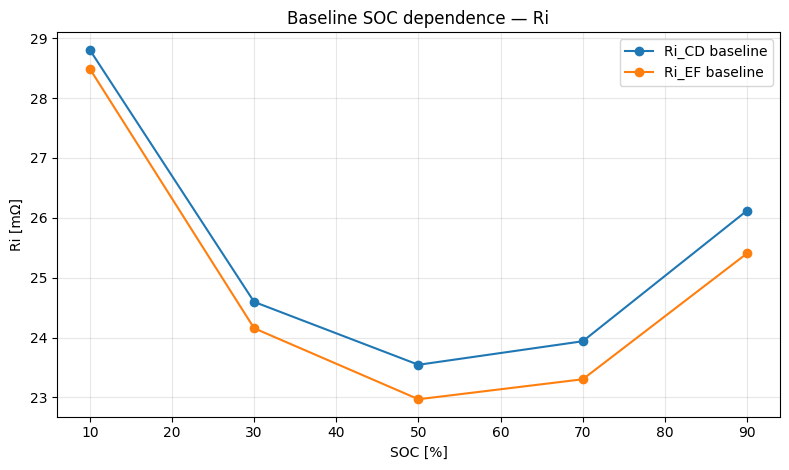

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/multi_soc_baseline_Ri_vs_SOC.png


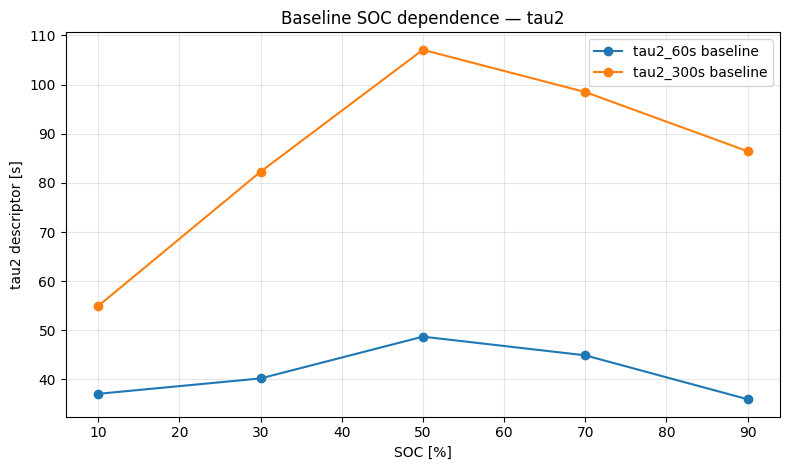

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/multi_soc_baseline_tau2_vs_SOC.png


In [10]:
# Cell 10 — Baseline SOC-dependence audit（baseline Ri 与 tau2 的 SOC 依赖审计）

baseline_soc = drift_table[drift_table["case"] == "baseline"].copy()
baseline_soc = baseline_soc.sort_values("soc_percent")

fig, ax1 = plt.subplots(figsize=(8, 4.8))

ax1.plot(
    baseline_soc["soc_percent"],
    baseline_soc["Ri_CD_mohm"],
    marker="o",
    label="Ri_CD baseline",
)

ax1.plot(
    baseline_soc["soc_percent"],
    baseline_soc["Ri_EF_mohm"],
    marker="o",
    label="Ri_EF baseline",
)

ax1.set_xlabel("SOC [%]")
ax1.set_ylabel("Ri [mΩ]")
ax1.set_title("Baseline SOC dependence — Ri")
ax1.grid(True, alpha=0.3)
ax1.legend()

fig.tight_layout()
fig_path = FIGURES / "multi_soc_baseline_Ri_vs_SOC.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8, 4.8))

ax.plot(
    baseline_soc["soc_percent"],
    baseline_soc["biexp60_tau2_s"],
    marker="o",
    label="tau2_60s baseline",
)

ax.plot(
    baseline_soc["soc_percent"],
    baseline_soc["biexp300_tau2_s"],
    marker="o",
    label="tau2_300s baseline",
)

ax.set_xlabel("SOC [%]")
ax.set_ylabel("tau2 descriptor [s]")
ax.set_title("Baseline SOC dependence — tau2")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "multi_soc_baseline_tau2_vs_SOC.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

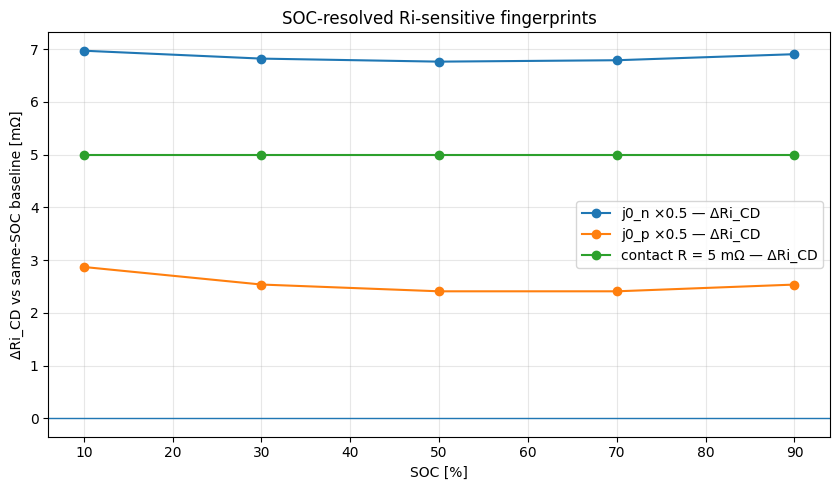

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/multi_soc_Ri_sensitive_fingerprints.png


In [11]:
# Cell 11 — Ri-sensitive fingerprints across SOC（j0/contact 扰动导致的 Ri 漂移随 SOC 的变化）

ri_cases = [
    ("j0_n_x0p5", "j0_n ×0.5"),
    ("j0_p_x0p5", "j0_p ×0.5"),
    ("contact_R_5mOhm", "contact R = 5 mΩ"),
]

fig, ax = plt.subplots(figsize=(8.5, 5))

for case_name, label in ri_cases:
    sub = drift_table[drift_table["case"] == case_name].copy()
    sub = sub.sort_values("soc_percent")

    ax.plot(
        sub["soc_percent"],
        sub["Ri_CD_mohm_delta"],
        marker="o",
        label=f"{label} — ΔRi_CD",
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("SOC [%]")
ax.set_ylabel("ΔRi_CD vs same-SOC baseline [mΩ]")
ax.set_title("SOC-resolved Ri-sensitive fingerprints")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "multi_soc_Ri_sensitive_fingerprints.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

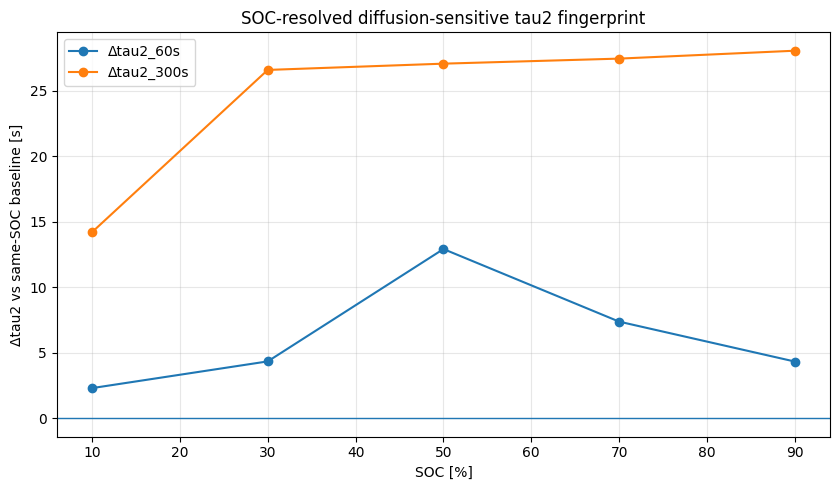

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/multi_soc_Ds_p_tau2_fingerprint.png


In [12]:
# Cell 12 — Diffusion-sensitive tau2 fingerprint across SOC（Ds_p 扰动导致的 tau2 漂移随 SOC 的变化）

ds_sub = drift_table[drift_table["case"] == "Ds_p_x0p5"].copy()
ds_sub = ds_sub.sort_values("soc_percent")

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(
    ds_sub["soc_percent"],
    ds_sub["biexp60_tau2_s_delta"],
    marker="o",
    label="Δtau2_60s",
)

ax.plot(
    ds_sub["soc_percent"],
    ds_sub["biexp300_tau2_s_delta"],
    marker="o",
    label="Δtau2_300s",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("SOC [%]")
ax.set_ylabel("Δtau2 vs same-SOC baseline [s]")
ax.set_title("SOC-resolved diffusion-sensitive tau2 fingerprint")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "multi_soc_Ds_p_tau2_fingerprint.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [13]:
# Cell 13 — Fingerprint stability audit table（机制指纹跨 SOC 稳定性审计表）

fingerprint_specs = [
    {
        "case": "Ds_p_x0p5",
        "fingerprint": "diffusion-sensitive tau2_60s",
        "metric": "biexp60_tau2_s_delta",
        "expected_sign": "positive",
    },
    {
        "case": "Ds_p_x0p5",
        "fingerprint": "diffusion-sensitive tau2_300s",
        "metric": "biexp300_tau2_s_delta",
        "expected_sign": "positive",
    },
    {
        "case": "j0_n_x0p5",
        "fingerprint": "negative kinetic Ri_CD",
        "metric": "Ri_CD_mohm_delta",
        "expected_sign": "positive",
    },
    {
        "case": "j0_p_x0p5",
        "fingerprint": "positive kinetic Ri_CD",
        "metric": "Ri_CD_mohm_delta",
        "expected_sign": "positive",
    },
    {
        "case": "contact_R_5mOhm",
        "fingerprint": "pure contact Ri_CD",
        "metric": "Ri_CD_mohm_delta",
        "expected_sign": "positive",
    },
    {
        "case": "contact_R_5mOhm",
        "fingerprint": "contact overpotential",
        "metric": "contact_overpotential_absmax_mV_delta",
        "expected_sign": "positive",
    },
]

stability_rows = []

for spec in fingerprint_specs:
    sub = drift_table[drift_table["case"] == spec["case"]].copy()
    sub = sub.sort_values("soc_percent")

    values = sub[spec["metric"]].values

    if spec["expected_sign"] == "positive":
        sign_stable = bool(np.all(values > 0))
    elif spec["expected_sign"] == "negative":
        sign_stable = bool(np.all(values < 0))
    else:
        sign_stable = None

    mean_val = float(np.mean(values))
    min_val = float(np.min(values))
    max_val = float(np.max(values))
    range_val = max_val - min_val

    if abs(mean_val) > 1e-12:
        cv_pct = float(np.std(values) / abs(mean_val) * 100)
    else:
        cv_pct = np.nan

    stability_rows.append(
        {
            "case": spec["case"],
            "fingerprint": spec["fingerprint"],
            "metric": spec["metric"],
            "sign_stable": sign_stable,
            "min_value": min_val,
            "max_value": max_val,
            "mean_value": mean_val,
            "range": range_val,
            "cv_pct": cv_pct,
            "values_by_soc": values.tolist(),
        }
    )

fingerprint_stability_table = pd.DataFrame(stability_rows)

out_csv = DATA / "multi_soc_fingerprint_stability_audit.csv"
fingerprint_stability_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fingerprint_stability_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/multi_soc_fingerprint_stability_audit.csv


,case,fingerprint,metric,sign_stable,min_value,max_value,mean_value,range,cv_pct,values_by_soc
0,Ds_p_x0p5,diffusion-sensitive tau2_60s,biexp60_tau2_s_delta,True,2.307871,12.923766,6.259298,1.061589e+01,5.919797e+01,"[2.307871354642444, 4.347638684975493, 12.9237..."
1,Ds_p_x0p5,diffusion-sensitive tau2_300s,biexp300_tau2_s_delta,True,14.212145,28.064479,24.682438,1.385233e+01,2.129910e+01,"[14.212144712874824, 26.597668953924114, 27.07..."
2,j0_n_x0p5,negative kinetic Ri_CD,Ri_CD_mohm_delta,True,6.760761,6.967844,6.847262,2.070830e-01,1.120684e+00,"[6.9678440921104645, 6.81825267583331, 6.76076..."
3,j0_p_x0p5,positive kinetic Ri_CD,Ri_CD_mohm_delta,True,2.407680,2.868732,2.551106,4.610514e-01,6.616949e+00,"[2.868731766590745, 2.536049887591396, 2.40778..."
4,contact_R_5mOhm,pure contact Ri_CD,Ri_CD_mohm_delta,True,5.000000,5.000000,5.000000,1.811884e-13,1.146074e-12,"[5.000000000000075, 4.999999999999982, 4.99999..."
5,contact_R_5mOhm,contact overpotential,contact_overpotential_absmax_mV_delta,True,25.000000,25.000000,25.000000,0.000000e+00,0.000000e+00,"[25.00000000000002, 25.00000000000002, 25.0000..."


In [14]:
# Cell 14 — Compact SOC-resolved conclusion table（SOC 维度机制指纹结论表）

compact_rows = [
    {
        "fingerprint_family": "baseline",
        "primary_observation": "Ri and tau2 are SOC-dependent even without perturbation",
        "soc_stability": "not constant",
        "interpretation": "same-SOC baseline comparison is mandatory",
    },
    {
        "fingerprint_family": "Ds_p_x0p5",
        "primary_observation": "tau2 increases at all SOC points",
        "soc_stability": "sign-stable but magnitude state-dependent",
        "interpretation": "diffusion-sensitive relaxation fingerprint persists, but strength depends on SOC",
    },
    {
        "fingerprint_family": "j0_n_x0p5",
        "primary_observation": "Ri increases at all SOC points",
        "soc_stability": "sign-stable and magnitude relatively stable",
        "interpretation": "negative-electrode kinetic fingerprint is robust across tested SOC range",
    },
    {
        "fingerprint_family": "j0_p_x0p5",
        "primary_observation": "Ri increases at all SOC points, weaker than j0_n",
        "soc_stability": "sign-stable and magnitude relatively stable",
        "interpretation": "positive-electrode kinetic fingerprint is observable but weaker",
    },
    {
        "fingerprint_family": "contact_R_5mOhm",
        "primary_observation": "Ri increases by exactly 5 mΩ at all SOC points",
        "soc_stability": "SOC-invariant",
        "interpretation": "pure ohmic/contact fingerprint is independent of SOC under this protocol",
    },
]

multi_soc_compact_conclusion = pd.DataFrame(compact_rows)

out_csv = DATA / "multi_soc_compact_conclusion_table.csv"
multi_soc_compact_conclusion.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(multi_soc_compact_conclusion)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/multi_soc_compact_conclusion_table.csv


,fingerprint_family,primary_observation,soc_stability,interpretation
0,baseline,Ri and tau2 are SOC-dependent even without per...,not constant,same-SOC baseline comparison is mandatory
1,Ds_p_x0p5,tau2 increases at all SOC points,sign-stable but magnitude state-dependent,diffusion-sensitive relaxation fingerprint per...
2,j0_n_x0p5,Ri increases at all SOC points,sign-stable and magnitude relatively stable,negative-electrode kinetic fingerprint is robu...
3,j0_p_x0p5,"Ri increases at all SOC points, weaker than j0_n",sign-stable and magnitude relatively stable,positive-electrode kinetic fingerprint is obse...
4,contact_R_5mOhm,Ri increases by exactly 5 mΩ at all SOC points,SOC-invariant,pure ohmic/contact fingerprint is independent ...


# Notebook 08 Conclusion

This notebook extends the mechanism-to-observable fingerprint scan from a single SOC point to multiple SOC points.

The tested SOC range was:

- SOC = 10%
- SOC = 30%
- SOC = 50%
- SOC = 70%
- SOC = 90%

The tested perturbation cases were:

- `baseline`
- `Ds_p_x0p5`
- `j0_n_x0p5`
- `j0_p_x0p5`
- `contact_R_5mOhm`

## Key findings

### 1. Baseline observables are SOC-dependent

Even without perturbation, both `Ri` and `tau2` vary with SOC.

The baseline `Ri` shows a U-shaped SOC dependence:

- higher at low SOC,
- lower around mid SOC,
- higher again toward high SOC.

The baseline `tau2` descriptors also vary with SOC, especially `tau2_300s`.

This confirms that mechanism fingerprints must be evaluated relative to the same-SOC baseline. Cross-SOC comparison of absolute values alone is not sufficient.

### 2. Positive solid diffusion perturbation is sign-stable but magnitude-dependent

For `Ds_p_x0p5`, the diffusion-sensitive fingerprint is preserved across all tested SOC points:

- `tau2_60s` increases at every SOC.
- `tau2_300s` increases at every SOC.

However, the magnitude of the increase is strongly SOC-dependent.

The `tau2_60s` drift ranges from approximately 2.3 s to 12.9 s, with the strongest response near SOC = 50%.

The `tau2_300s` drift remains positive across all SOC points and is generally larger than the 60 s descriptor drift.

Therefore, the `Ds_p` fingerprint is:

`sign-stable but magnitude state-dependent`

This means that positive solid diffusion limitation remains observable, but its sensitivity depends on SOC.

### 3. Negative exchange-current perturbation is SOC-stable in Ri response

For `j0_n_x0p5`, `Ri_CD` increases at all SOC points.

The absolute `Ri_CD` drift remains very stable across SOC:

- minimum drift: approximately 6.76 mΩ
- maximum drift: approximately 6.97 mΩ

This indicates that the negative-electrode kinetic / charge-transfer fingerprint is robust across the tested SOC range.

### 4. Positive exchange-current perturbation is weaker but sign-stable

For `j0_p_x0p5`, `Ri_CD` also increases at all SOC points.

The magnitude is smaller than the `j0_n` perturbation:

- minimum drift: approximately 2.41 mΩ
- maximum drift: approximately 2.87 mΩ

This supports a positive-electrode kinetic fingerprint that is observable but weaker than the negative-electrode kinetic fingerprint under the present HPPC protocol.

### 5. Contact resistance fingerprint is SOC-invariant

For `contact_R_5mOhm`, the extracted resistance increase is exactly 5 mΩ at all tested SOC points.

The contact overpotential is exactly 25 mV at all SOC points under the 5 A pulse.

This confirms that contact resistance behaves as a pure ohmic contribution:

`Contact resistance increase → Ri increase independent of SOC`

The `tau` descriptors remain unchanged.

## Fingerprint stability classification

The multi-SOC scan supports the following classification:

| Fingerprint family | SOC stability |
|---|---|
| baseline | SOC-dependent |
| `Ds_p_x0p5` | sign-stable, magnitude state-dependent |
| `j0_n_x0p5` | sign-stable, magnitude relatively stable |
| `j0_p_x0p5` | sign-stable, weaker but stable |
| `contact_R_5mOhm` | SOC-invariant |

## Interpretation boundary

This notebook does not establish full aging evolution or SOH progression.

The results are valid for:

- Chen2020 DFN,
- default isothermal 25 °C condition,
- 1C 10 s discharge pulse,
- 600 s relaxation,
- selected SOC points,
- selected perturbation cases.

The correct conclusion is:

Under the present HPPC protocol, selected mechanism-to-observable fingerprints remain sign-stable across SOC, but their magnitude stability differs by mechanism family.

## Next step

The next stage should convert these results into a reusable fingerprint-map structure.

A suitable next notebook is:

`09_fingerprint_map_summary.ipynb`

The purpose would be to consolidate:

- baseline SOC dependence,
- Ri-sensitive fingerprints,
- tau-sensitive fingerprints,
- SOC stability classification,
- mechanism-to-observable interpretation rules.